# Simplified Greedy Matching Algorithm

This notebook demonstrates the **Simplified Greedy** distributed matching algorithm.

## Algorithm Overview

**Key Characteristics:**
- Each node bids to its highest-weight neighbor each round
- **Mutual bids match immediately** (both nodes match each other)
- Edge-based tie-breaking prevents circular bidding
- Fast convergence (typically 4-10 rounds)
- Guarantees maximal matching
- Protocol: BID only (2 messages total per successful match)


## Protocol: Simplified Mutual Bidding

**How it works:**

1. **Each round**: Unmatched nodes bid to their best neighbor (by weight, then edge canonical form)
2. **Mutual match detection**: If both nodes bid to each other → instant match
3. **Termination**: When all nodes matched or no progress

**Example:**
```
Round 1: Node A → B, Node B → C, Node C → A (no mutual)
Round 2: Nodes change targets based on new information
        Node B → A, Node A → B (MUTUAL!) → A and B match
Round 3: Node C continues with remaining unmatched neighbors
```

**Why it's fast**: Immediate matching on mutual bids eliminates waiting for ACCEPT/CONFIRM sequence.

In [11]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import networkx as nx
from src.graph import GraphManager
from src.simulation import Scheduler, SimulationConfig
from src.algorithms.implementations import GreedyMatching

## 1. Create Test Graph

Simple weighted graph for testing mutual bidding.

In [12]:
# Create a simple test graph
graph = GraphManager.create_empty_graph()

# Add vertices
vertices = [1, 2, 3, 4, 5, 6]
for v in vertices:
    graph.add_vertex(v)

# Add weighted edges
edges = [
    (1, 2, 10.0),
    (1, 3, 5.0),
    (2, 3, 8.0),
    (2, 4, 7.0),
    (3, 4, 9.0),
    (4, 5, 6.0),
    (5, 6, 11.0),
    (4, 6, 4.0),
]

for u, v, w in edges:
    graph.add_edge(u, v, w)

print(f"Graph created with {len(vertices)} vertices and {len(edges)} edges")

Graph created with 6 vertices and 8 edges


## 2. Visualize Initial Graph

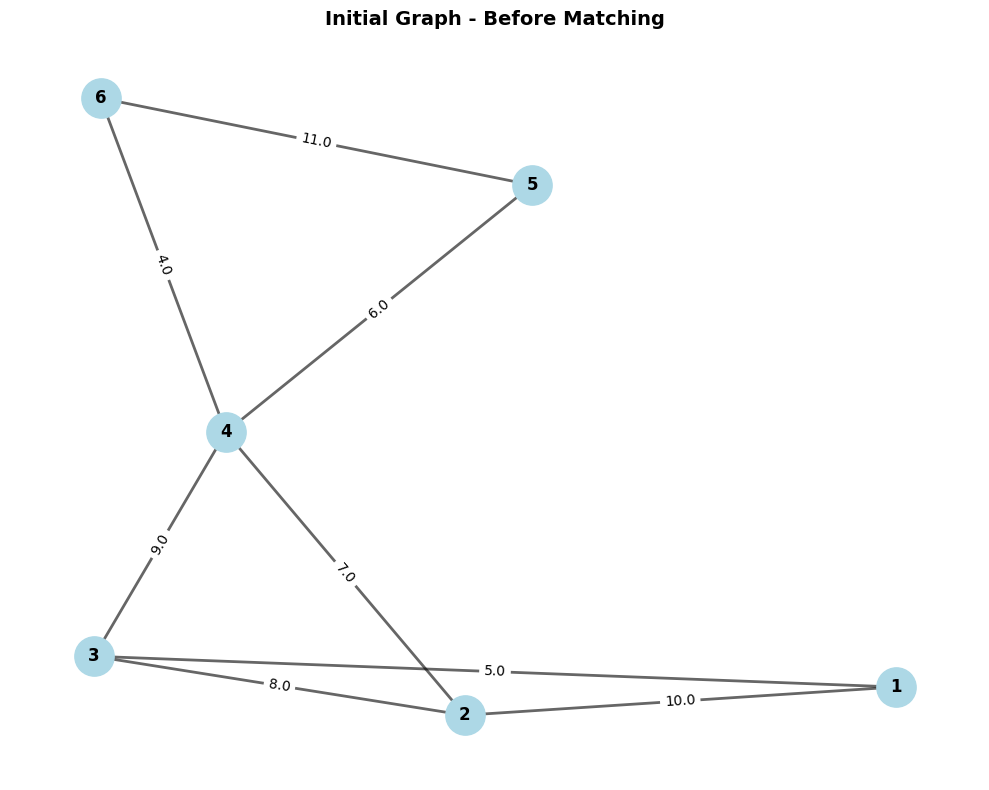

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Create NetworkX graph for visualization
G = graph._graph
pos = nx.spring_layout(G, seed=42, k=2, iterations=50)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=800, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax)

# Draw edges with weights
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, ax=ax)
edge_labels = {(u, v): f"{w:.1f}" for u, v, w in G.edges(data='weight')}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=10, ax=ax)

ax.set_title("Initial Graph - Before Matching", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Run Greedy Algorithm

In [14]:
# Create algorithm instance
algo = GreedyMatching(seed=42)

# Create simulation configuration
config = SimulationConfig(
    max_rounds=100,
    collect_snapshots=True,
    random_seed=42
)

# Run scheduler
scheduler = Scheduler(graph, algo, config)
rounds = scheduler.run_until_termination()

print(f"Algorithm converged in {rounds} rounds")
print(f"Termination reason: {scheduler._termination_reason}")

Algorithm converged in 2 rounds
Termination reason: all_nodes_inactive


## 4. Extract and Validate Matching

In [15]:
# Extract matching
matching = algo.extract_matching(scheduler.state_store, graph)

# Validate matching
is_valid, error_msg = algo.validate_matching(matching, graph)
print(f"Valid matching: {is_valid}")
if not is_valid:
    print(f"Error: {error_msg}")

# Check if maximal
is_maximal = algo.is_maximal_matching(matching, graph)
print(f"Is maximal: {is_maximal}")

# Calculate total weight
total_weight = sum(
    graph.get_edge_weight(u, v)
    for u, v in matching.items() if u < v
)
print(f"\nMatching pairs: {len(matching) // 2}")
print(f"Total weight: {total_weight:.2f}")
print(f"\nMatching: {matching}")

Valid matching: True
Is maximal: True

Matching pairs: 3
Total weight: 30.00

Matching: {1: 2, 2: 1, 3: 4, 4: 3, 5: 6, 6: 5}


## 5. Visualize Matched Graph

Show which nodes matched to each other.

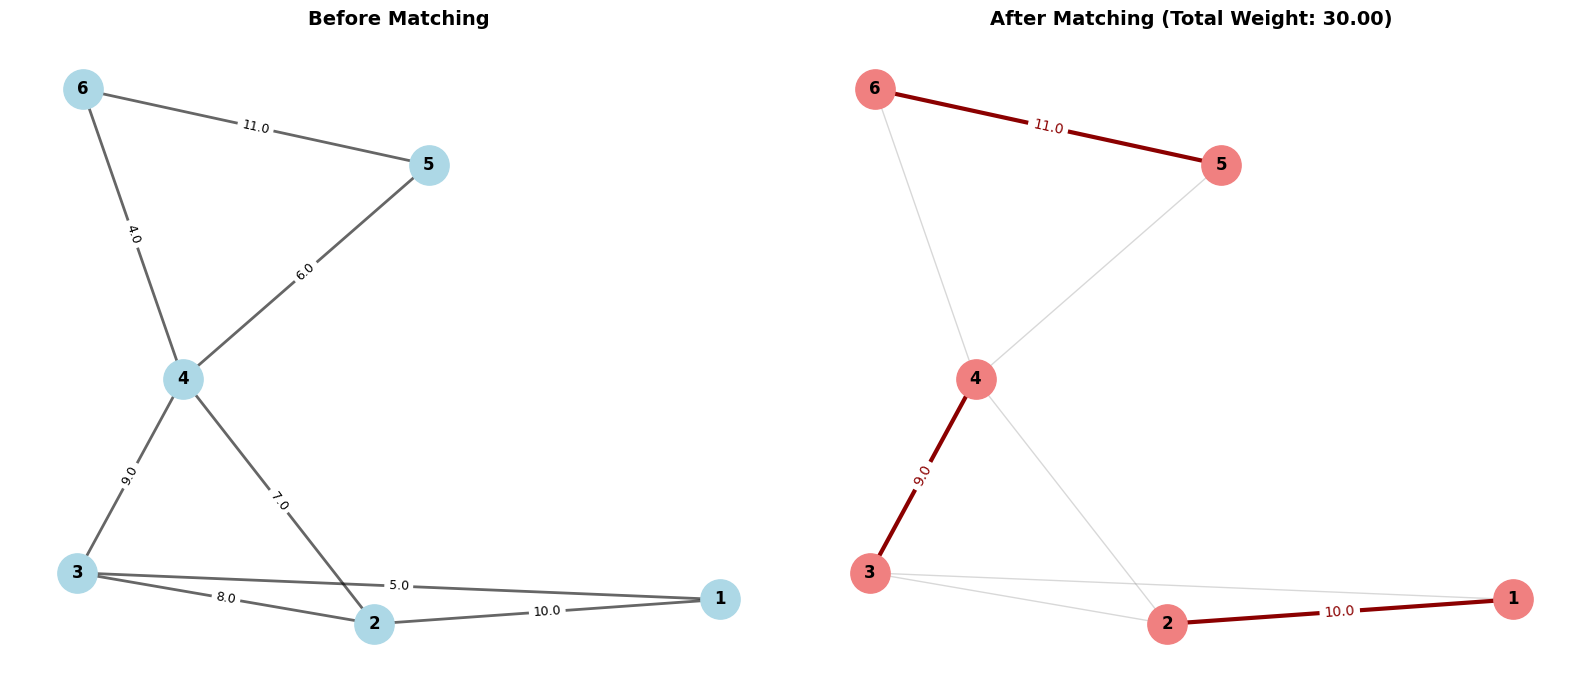

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Use the same layout for both graphs
G = graph._graph
pos = nx.spring_layout(G, seed=42, k=2, iterations=50)

# LEFT: Before matching
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=800, ax=ax1)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax1)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, ax=ax1)
edge_labels = {(u, v): f"{w:.1f}" for u, v, w in G.edges(data='weight')}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=9, ax=ax1)
ax1.set_title("Before Matching", fontsize=14, fontweight='bold')
ax1.axis('off')

# RIGHT: After matching
nx.draw_networkx_nodes(G, pos, node_color='lightcoral', node_size=800, ax=ax2)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax2)

# Draw all edges in light gray
nx.draw_networkx_edges(G, pos, width=1, alpha=0.3, edge_color='gray', ax=ax2)

# Highlight matched edges in red
matched_edges = [(u, v) for u, v in matching.items() if u < v]
nx.draw_networkx_edges(G, pos, edgelist=matched_edges, width=3, edge_color='darkred', ax=ax2)

# Draw edge labels only for matched edges
matched_labels = {(u, v): f"{graph.get_edge_weight(u, v):.1f}" for u, v in matched_edges}
nx.draw_networkx_edge_labels(G, pos, matched_labels, font_size=10, font_color='darkred', ax=ax2)

ax2.set_title(f"After Matching (Total Weight: {total_weight:.2f})", fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

## 6. Convergence Statistics

How many rounds and messages needed?

In [17]:
# Collect metrics
metrics = scheduler.metrics.get_all_metrics()

print("\n=== Algorithm Statistics ===")
print(f"Convergence Rounds: {rounds}")
print(f"Final Matched Pairs: {len(matching) // 2}")
print(f"Total Weight: {total_weight:.2f}")

# Calculate metrics summary
total_messages_sent = sum(m.messages_sent for m in metrics)
total_messages_received = sum(m.messages_received for m in metrics)
print(f"Total Messages Sent: {total_messages_sent}")
print(f"Total Messages Received: {total_messages_received}")
print(f"\nFinal Metrics:")
final_metric = metrics[-1]
print(f"  Active Nodes: {final_metric.active_nodes}")
print(f"  Matched Nodes: {final_metric.matched_nodes}")
print(f"  Dormant Nodes: {final_metric.dormant_nodes}")


=== Algorithm Statistics ===
Convergence Rounds: 2
Final Matched Pairs: 3
Total Weight: 30.00
Total Messages Sent: 24
Total Messages Received: 0

Final Metrics:
  Active Nodes: 0
  Matched Nodes: 0
  Dormant Nodes: 0


## 7. Convergence Over Time

Track matching progress per round.

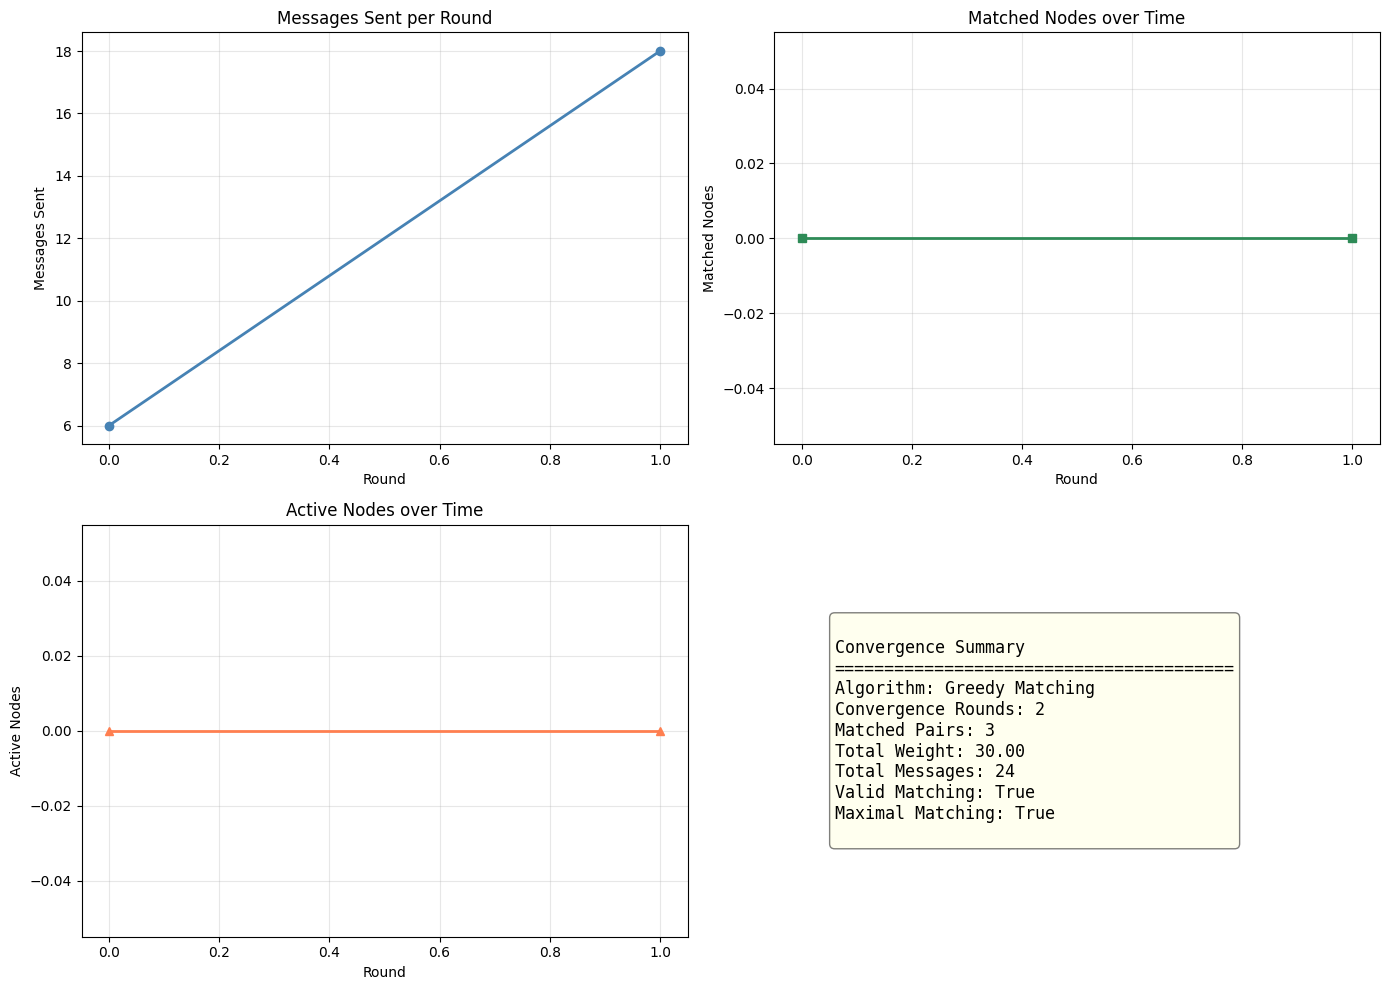

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

rounds_list = [m.round_num for m in metrics]
messages_sent = [m.messages_sent for m in metrics]
matched_nodes = [m.matched_nodes for m in metrics]
active_nodes = [m.active_nodes for m in metrics]

# Messages sent over time
axes[0, 0].plot(rounds_list, messages_sent, marker='o', linewidth=2, markersize=6, color='steelblue')
axes[0, 0].set_xlabel('Round')
axes[0, 0].set_ylabel('Messages Sent')
axes[0, 0].set_title('Messages Sent per Round')
axes[0, 0].grid(True, alpha=0.3)

# Matched nodes over time
axes[0, 1].plot(rounds_list, matched_nodes, marker='s', linewidth=2, markersize=6, color='seagreen')
axes[0, 1].set_xlabel('Round')
axes[0, 1].set_ylabel('Matched Nodes')
axes[0, 1].set_title('Matched Nodes over Time')
axes[0, 1].grid(True, alpha=0.3)

# Active nodes over time
axes[1, 0].plot(rounds_list, active_nodes, marker='^', linewidth=2, markersize=6, color='coral')
axes[1, 0].set_xlabel('Round')
axes[1, 0].set_ylabel('Active Nodes')
axes[1, 0].set_title('Active Nodes over Time')
axes[1, 0].grid(True, alpha=0.3)

# Convergence summary
axes[1, 1].axis('off')
summary_text = f"""
Convergence Summary
{'='*40}
Algorithm: Greedy Matching
Convergence Rounds: {rounds}
Matched Pairs: {len(matching) // 2}
Total Weight: {total_weight:.2f}
Total Messages: {total_messages_sent}
Valid Matching: {is_valid}
Maximal Matching: {is_maximal}
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.show()